In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker
import torchvision

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data import DataLoader, TensorDataset
import math

In [2]:
LEARNING_RATE = 0.001
BATCH_SIZE = 64
L2_LAMBDA = 0.0001
EPOCHS = 100
SEED = 42

In [3]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
set_seed(SEED)

dataset = fetch_openml(
    name="mushroom",
    version=1,
    as_frame=True,
    data_home="datasets"
)

X = dataset.data
y = dataset.target

features_train, features_val, targets_train, targets_val = train_test_split(
    dataset.data,
    dataset.target,
    test_size=0.1,
    random_state=SEED,
    stratify=dataset.target,
)

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

train_array = encoder.fit_transform(features_train)
val_array = encoder.transform(features_val)

train_targets = (targets_train.to_numpy() == "p").astype(np.float32)
val_targets = (targets_val.to_numpy() == "p").astype(np.float32)

train_dataset = TensorDataset(
    torch.from_numpy(train_array).float(),
    torch.from_numpy(train_targets).float(),
)

generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
)

val_dataset = TensorDataset(
    torch.from_numpy(val_array).float(),
    torch.from_numpy(val_targets).float(),
)

test_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [5]:
set_seed(SEED)

class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        x = self.flatten(x)
        return self.linear(x).squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
ROOT_DIR = "outputs/mashroom_norm"
TARGET_DIR = f"{ROOT_DIR}/{LEARNING_RATE}/{BATCH_SIZE}/{L2_LAMBDA}/{EPOCHS}/{SEED}"
os.makedirs(TARGET_DIR, exist_ok=True)

In [7]:
def L2_loss(model, outputs, targets, l2_lambda):
    bce = nn.functional.binary_cross_entropy_with_logits(outputs, targets)
    
    l2_reg = torch.tensor(0.0, device=outputs.device)
    for name, param in model.named_parameters():
        if 'weight' in name:
            l2_reg += torch.sum(param ** 2)
            
    return bce + 0.5 * l2_lambda * l2_reg

# No Full Grad SVRG

In [8]:
set_seed(SEED)
class NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["hat_a"] = torch.zeros_like(p)
                    state['hat_w'] = torch.clone(p)

                state["a"].zero_()
                state["t"] = 0


    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["z"] = torch.zeros_like(p)
                state['hat_w'] = torch.clone(p)

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            loss = loss_func(model, Y, T, L2_LAMBDA) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue


                    grad = p.grad.detach()
                    state = self.state[p]
                    state["z"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["z"].div_(total_data)


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_w"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(model, Y, T, L2_LAMBDA)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["snapshot_grad"] = torch.clone(p.grad.detach())
                    p.copy_(state["w"])


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state["hat_a"].copy_(state["a"])
                state['hat_w'] = torch.clone(p).detach()


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                a = state['a']
                hat_a = state["hat_a"]
                snapshot_grad = state["snapshot_grad"]
                t = state["t"]

                v = grad - snapshot_grad + hat_a
                p.sub_(v, alpha = lr)
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [9]:
set_seed(SEED)
NFG_SVRG_DIR = f"{TARGET_DIR}/NFG_SVRG"
os.makedirs(NFG_SVRG_DIR, exist_ok=True)

if not os.path.exists(f"{NFG_SVRG_DIR}/result.json"):
    input_dim = train_array.shape[1]
    model = LogisticRegressionModel(input_dim=input_dim).to(device)
    criterion = L2_loss
    optimizer = NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

    NFG_SVRG_train_loss_history = []
    NFG_SVRG_test_loss_history = []
    NFG_SVRG_train_acc_history = []
    NFG_SVRG_test_acc_history = []
    NFG_SVRG_x = []
    fg_count = 0
    NFG_SVRG_norm_history = []

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.init_epoch()
        optimizer.calc_full_grads(model, train_loader, criterion)

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(model, Y, T, L2_LAMBDA)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = (Y >= 0).float()
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        optimizer.end_epoch()

    # --- ここから追加: 平均勾配 a とフル勾配 full_grad の差の全体ノルムを計算 ---
        diff_norm_sq_sum = 0.0
        for group in optimizer.param_groups:
            for p in group['params']:
                state = optimizer.state[p]
                if "a" in state and "z" in state:
                    # 平均勾配 a と フル勾配 full_grad の差を計算
                    diff = state["a"] - state["z"]
                    # 差の2乗和を累積
                    diff_norm_sq_sum += torch.sum(diff ** 2).item()
        
        # 全体の2乗和の平方根をとって L2 ノルムとする
        epoch_diff_norm = math.sqrt(diff_norm_sq_sum)
        NFG_SVRG_norm_history.append(epoch_diff_norm)
        # --- ここまで追加 ---        

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        NFG_SVRG_x.append(fg_count)
        NFG_SVRG_train_loss_history.append(train_loss)
        NFG_SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)
            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = nn.functional.binary_cross_entropy_with_logits(Y, T)

                test_loss += loss.item()

                pred = (Y >= 0).float()
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        test_loss /= len(test_loader)
        test_acc = correct / total

        NFG_SVRG_test_loss_history.append(test_loss)
        NFG_SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}, norm: {epoch_diff_norm}")

        if fg_count >= EPOCHS:
            break

    os.makedirs(NFG_SVRG_DIR, exist_ok=True)

    with open(f"{NFG_SVRG_DIR}/result.json", "w") as f:
        json.dump({
            'norm': NFG_SVRG_norm_history,
            "x": NFG_SVRG_x
        }, f, indent = 4)

epoch: 1


100%|██████████| 13/13 [00:00<00:00, 910.45it/s, loss=0.693, acc=0.6]


Train Loss: 0.6787, Acc: 0.6031 | Test Loss: 0.6787, Acc: 0.6002, norm: 0.0025914640358687666
epoch: 2


100%|██████████| 13/13 [00:00<00:00, 898.35it/s, loss=0.661, acc=0.733]


Train Loss: 0.6616, Acc: 0.6731 | Test Loss: 0.6450, Acc: 0.7331, norm: 0.015139021277451504
epoch: 3


...

Train Loss: 0.2439, Acc: 0.9203 | Test Loss: 0.2430, Acc: 0.9139, norm: 0.0016087473232832682
epoch: 49


100%|██████████| 13/13 [00:00<00:00, 589.31it/s, loss=0.277, acc=0.916]


Train Loss: 0.2417, Acc: 0.9208 | Test Loss: 0.2407, Acc: 0.9164, norm: 0.0018326826800960999
epoch: 50


100%|██████████| 13/13 [00:00<00:00, 883.83it/s, loss=0.274, acc=0.916]

Train Loss: 0.2393, Acc: 0.9219 | Test Loss: 0.2385, Acc: 0.9164, norm: 0.002078695947489508


# ASAI-SVRG

In [10]:
set_seed(SEED)
class ASAI_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)


    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["hat_a"] = torch.zeros_like(p)
                    state["z"] = torch.clone(p.detach())
                    state["hat_z"] = torch.clone(p.detach())

                state["a"].zero_()
                state["z"].zero_()
                state["t"] = 0


    def calc_snapshot_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["w"] = torch.clone(p).detach()
                    p.copy_(state["hat_z"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(model, Y, T, L2_LAMBDA)
        loss.backward()

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["snapshot_grad"] = torch.clone(p.grad.detach())
                    p.copy_(state["w"])

    
    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        # 【追加】勾配計算の前に、現在のパラメータを退避し、平均パラメータ(prev_z)をモデルにセット
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["full_grad"] = torch.zeros_like(p)
                    # 現在のパラメータを保持し、モデルの重みを prev_z に差し替える
                    if "prev_z" in state:
                        state["current_p_temp"] = torch.clone(p.detach())
                        p.copy_(state["hat_z"])

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            # 平均の誤差にデータ数を掛け総和に変換 (loss_funcがmeanを返す前提であればこれで正解です)
            loss = loss_func(model, Y, T, L2_LAMBDA) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue

                    grad = p.grad.detach()
                    state = self.state[p]
                    state["full_grad"].add_(grad)

        # 【追加】計算完了後、フル勾配をデータ数で割り、モデルのパラメータを元の状態に復元
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["full_grad"].div_(total_data)
                    
                    # 退避しておいた元のパラメータを復元する
                    if "current_p_temp" in state:
                        p.copy_(state["current_p_temp"])
                        del state["current_p_temp"] # 不要になったので削除


    def end_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                state["hat_a"].copy_(state["a"])
                state['hat_z'].copy_(state["z"])


    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]
                a = state['a']
                prev_a = state["hat_a"]
                prev_grad = state["snapshot_grad"]
                z = state["z"]
                t = state["t"]

                v = grad - prev_grad + prev_a
                p.sub_(v, alpha = lr)
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))
                z.mul_(t / (t+1)).add_(p, alpha = 1 / (t+1))

                state["t"] += 1

        return loss

In [11]:
set_seed(SEED)
ASAI_SVRG_DIR = f"{TARGET_DIR}/ASAI_SVRG"
os.makedirs(ASAI_SVRG_DIR, exist_ok=True)

if not os.path.exists(f"{ASAI_SVRG_DIR}/result.json"):
    set_seed(SEED)
    input_dim = train_array.shape[1]
    model = LogisticRegressionModel(input_dim=input_dim).to(device)
    criterion = L2_loss
    optimizer = ASAI_SVRG(model.parameters(), lr = LEARNING_RATE)

    ASAI_SVRG_train_loss_history = []
    ASAI_SVRG_test_loss_history = []
    ASAI_SVRG_train_acc_history = []
    ASAI_SVRG_test_acc_history = []
    ASAI_SVRG_x = []
    ASAI_SVRG_norm_history = []
    fg_count = 0

    for epoch in range(EPOCHS):
        print(f"epoch: {epoch + 1}")
        model.train()
        train_loss, correct, total = 0, 0, 0

        optimizer.init_epoch()
        optimizer.calc_full_grads(model, train_loader, criterion)

        pb = tqdm(train_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            optimizer.calc_snapshot_grads(model, X, T, criterion)

            optimizer.zero_grad()
            Y = model(X)
            loss = criterion(model, Y, T, L2_LAMBDA)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            pred = (Y >= 0).float()
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        optimizer.end_epoch()

    # --- ここから追加: 平均勾配 a とフル勾配 full_grad の差の全体ノルムを計算 ---
        diff_norm_sq_sum = 0.0
        for group in optimizer.param_groups:
            for p in group['params']:
                state = optimizer.state[p]
                if "a" in state and "z" in state:
                    # 平均勾配 a と フル勾配 full_grad の差を計算
                    diff = state["a"] - state["full_grad"]
                    # 差の2乗和を累積
                    diff_norm_sq_sum += torch.sum(diff ** 2).item()
        
        # 全体の2乗和の平方根をとって L2 ノルムとする
        epoch_diff_norm = math.sqrt(diff_norm_sq_sum)
        ASAI_SVRG_norm_history.append(epoch_diff_norm)
        # --- ここまで追加 ---

        fg_count += 2
        train_loss /= len(train_loader)
        train_acc = correct / total

        ASAI_SVRG_x.append(fg_count)
        ASAI_SVRG_train_loss_history.append(train_loss)
        ASAI_SVRG_train_acc_history.append(train_acc)


        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            pb = tqdm(test_loader)

            backup = []
            with torch.no_grad():
                for group in optimizer.param_groups:
                    for p in group['params']:
                        state = optimizer.state[p]
                        backup.append(p.clone())
                        p.copy_(state["z"])

            for X, T in pb:
                X, T = X.to(device), T.to(device)

                Y = model(X)
                loss = nn.functional.binary_cross_entropy_with_logits(Y, T)

                test_loss += loss.item()

                pred = (Y >= 0).float()
                correct += (pred == T).sum().item()
                total += T.size(0)

                pb.set_postfix({"loss": loss.item(), "acc": correct / total})

            with torch.no_grad():
                i = 0
                for group in optimizer.param_groups:
                    for p in group['params']:
                        p.copy_(backup[i])
                        i += 1

        test_loss /= len(test_loader)
        test_acc = correct / total

        ASAI_SVRG_test_loss_history.append(test_loss)
        ASAI_SVRG_test_acc_history.append(test_acc)

        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}, norm: {epoch_diff_norm}")

        if fg_count >= EPOCHS:
            break

    with open(f"{ASAI_SVRG_DIR}/result.json", "w") as f:
        json.dump({
            'norm': ASAI_SVRG_norm_history,
            "x": ASAI_SVRG_x
        }, f, indent = 4)

epoch: 1


100%|██████████| 13/13 [00:00<00:00, 833.26it/s, loss=0.693, acc=0.6]


Train Loss: 0.6786, Acc: 0.6031 | Test Loss: 0.6787, Acc: 0.6002, norm: 0.003530595122322731
epoch: 2


100%|██████████| 13/13 [00:00<00:00, 922.34it/s, loss=0.677, acc=0.661]


Train Loss: 0.6616, Acc: 0.6764 | Test Loss: 0.6614, Acc: 0.6605, norm: 0.015715698968685615
epoch: 3


...

Train Loss: 0.2449, Acc: 0.9205 | Test Loss: 0.2454, Acc: 0.9139, norm: 0.001544431122729284
epoch: 49


100%|██████████| 13/13 [00:00<00:00, 851.94it/s, loss=0.279, acc=0.916]


Train Loss: 0.2434, Acc: 0.9212 | Test Loss: 0.2431, Acc: 0.9164, norm: 0.0034062849129437734
epoch: 50


100%|██████████| 13/13 [00:00<00:00, 848.31it/s, loss=0.276, acc=0.916]

Train Loss: 0.2406, Acc: 0.9223 | Test Loss: 0.2408, Acc: 0.9164, norm: 0.0018767083394618115


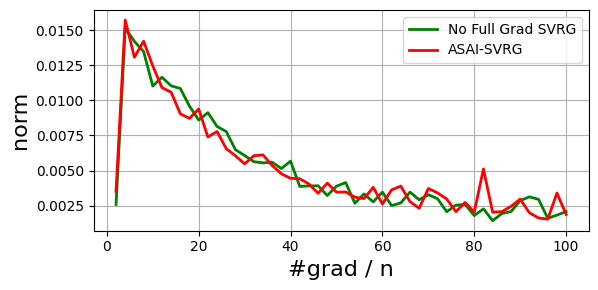

In [12]:
fig = plt.figure(figsize = (6, 3))
ax = fig.add_subplot()
ax.plot(NFG_SVRG_x , NFG_SVRG_norm_history, label = "No Full Grad SVRG", c='green', linewidth = 2)
ax.plot(ASAI_SVRG_x, ASAI_SVRG_norm_history, label = "ASAI-SVRG", c='red', linewidth = 2)
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("norm", fontsize=16)
ax.set_title("" ,fontsize=16)
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()